In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

import scipy.stats as st

from matplotlib.colors import LinearSegmentedColormap


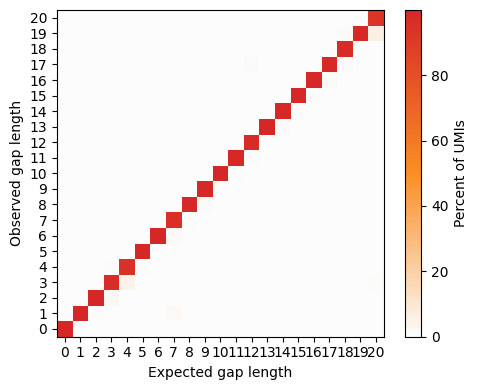

In [2]:
df = pd.read_csv('../../1_figure_CL_proof_of_concept/data/CL3_GapLength_Betaine_expected_observed.csv')

gap_length_counts = df.groupby(['expected_gap_length', 'observed_gap_length']).size().reset_index(name='count')
gap_length_pivot = gap_length_counts.pivot(index='observed_gap_length', columns='expected_gap_length', values='count').fillna(0).iloc[0:21, 0:21].sort_index(ascending=False)
gap_length_pivot_normalized = gap_length_pivot.div(gap_length_pivot.sum(axis=0), axis=1) * 100
to_plot = gap_length_pivot_normalized    

# Values actually being plotted
expected_vals = gap_length_pivot_normalized.columns[:21]
observed_vals = gap_length_pivot_normalized.index[:21]

fig, ax = plt.subplots(figsize=(5, 4))

colors = ['#FCFCFC', '#FFEDB0', '#FFDF5F', '#FEC510', '#FA8E24', '#F14C2B', '#DA2828', '#BE2222', '#A31D1D']

colors = ['#FCFCFC', '#FA8E24', 'tab:red']

cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)
im = ax.imshow(
    to_plot,
    cmap=cmap,
    origin='upper',  # matches your descending expected_gap_length
    # vmin=-1,
    # vmax=2
)

# ---- Axis ticks ----
ax.set_xticks(np.arange(len(expected_vals)))
ax.set_yticks(np.arange(len(observed_vals)))

ax.set_xticklabels(expected_vals.astype(int))
ax.set_yticklabels(observed_vals.astype(int))

# ---- Axis labels ----
ax.set_xlabel("Expected gap length")
ax.set_ylabel("Observed gap length")

# ---- Colorbar ----
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Percent of UMIs")

plt.tight_layout()

plt.savefig('../plots/gaplength_expected_vs_observed_heatmap.pdf', transparent = False, bbox_inches='tight')

In [3]:
### get proportion of gapfills that are correct length
gap_length_counts.loc[gap_length_counts['expected_gap_length'] == gap_length_counts['observed_gap_length']]['count'].sum() / gap_length_counts['count'].sum()

0.9853015918884234